# Network Biology: Lecture 1  
## Introduction to Network Biology and Biological Networks
In this lecture, we will begin building the conceptual and computational foundation to understand network biology. Networks are formal representations of relationships; diagrams that enable use to think about the relationships that exist among biological entities, and their usefulness depends on whether those relationships are biologically meaningful.
We will use Python, NetworkX, Cytoscape, and RNA-seq data associated with the **GSE88741 melanoma dataset** to construct and visualize a gene co-expression network. Our goal today is to understand what kind of biological claim is being made when we make a connection, known in network biology as an edge, between two genes.

---
## Goals
By the end of this lecture, you should be able to:
1. Explain what nodes and edges represent in a biological network.
2. Distinguish a network visualization from a network model.
3. Load and prepare a gene expression dataset for network construction.
4. Build a simple gene co-expression network from RNA-seq data.
5. Interpret an adjacency matrix as a formal representation of network structure.
6. Visualize a biological network in Python and Cytoscape.
7. Explain what is gained, and what is lost, when gene expression data are converted into a network.

---
## What is a Network?

A **network** is a system that's defined by two primary elements:

- **Nodes( (or Vertices):** These are the objects or entities within the network. In the context of bioinformatics, nodes might represent genes, proteins, individuals within a population, species within an ecosystem, and so forth.

- **Edges (or Links):** These represent the connections or relationships between the nodes. Depending on the context, edges might represent physical interactions, genetic interactions, predator-prey relationships, and more.

>In other words, a network is a set of objects (`the nodes`), along with a description of how these objects are connected (`the edges`).

- **Network Topology:** The physical or logical layout of a network, i.e., how its nodes and edges are `arranged`.
- **Graph:** The mathematical representation of a network. A graph is an abstract representation that encapsulates the idea of (binary) relationships between objects.


Understanding these fundamental [concepts](https://en.wikipedia.org/wiki/Glossary_of_graph_theory) will be the foundation for your further exploration into the exciting world of network science.

Additional resources useful for deep diving into the world of network science:
1. Albert-László Barabási's [Network Science](http://networksciencebook.com) online textbook.
2. [Network X](https://networkx.org). A python package for the creation, manipulation, and study of the structure, dynamics, and functions of complex networks.
---
---
## Biological Networks as Data Structures
Before constructing a network, we need to define what the network represents.
A biological network contains:
| Network term | Biological meaning |
|---|---|
| Node | A biological entity, such as a gene, protein, metabolite, or cell |
| Edge | A relationship between two entities |
| Edge weight | The strength of a relationship |
| Direction | Whether the relationship has a source and target |
| Attribute | Additional information attached to a node or edge |
In this lecture, our nodes will be **genes**.
Our edges will represent **co-expression relationships** inferred from RNA-seq data.
---
## Biological Motivation
The dataset used in this lecture comes from **GSE88741**, a study of melanoma-associated gene expression programs. We will use this dataset as a biological case study for asking a broader question:
> Can relationships among genes reveal structure that is not obvious from individual gene measurements alone?
In a gene co-expression network, genes are represented as **nodes**, and relationships between genes are represented as **edges**. These edges are often inferred from correlated expression patterns across samples.
This immediately raises an important question:
> If two genes are connected in a co-expression network, what exactly are we claiming biologically?
That question will guide the entire lecture.

In [2]:
# Import required libraries, drives, etc.

import numpy as np              # a Python library for numerical operations.
import pandas as pd             # a library for data manipulation and analysis.
import matplotlib.pyplot as plt # a 2D plotting library to create static, animated, and interactive visualizations.
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
import seaborn as sns           # a Python data visualization library based on matplotlib, for better aesthetic and informative statistical graphics.

import collections              # for high-performance container datatypes.

# Setting Matplotlib to use inline plotting.
# This means the output of plotting commands is displayed inline within frontends like the Jupyter notebook, directly below the code cell that produced it.
%matplotlib inline

# Allowing multiple outputs from the same cell, rather than just the last one run.
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from IPython.display import HTML
from IPython.display import Image

import networkx as nx           # a Python package for the creation, manipulation, and study of the structure, dynamics, and functions of complex networks.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 73.8 MB/s  0:00:00


# Network Analysis and Its Unique Insights

Network analysis is a powerful tool offering unique insights in various systems where relationships or interactions between entities are central. These systems span **social networks**, **transportation networks**, and **biological systems**.

---

## Case Study: Pandemic Spread Through a Population

Let's consider a relevant case: a pandemic spreading through a population, such as the COVID-19 situation.

**Traditional Epidemiological Models:** These models employ statistics and probabilities to predict disease spread speed within a population. However, they usually make simplifying assumptions about human interactions, often presuming any given individual is equally likely to interact with anyone else in the population.

**Reality Check:** This isn't true. People interact within fairly limited social networks. We see a particular set of people regularly, and these people have their own networks, creating a chain of connections. Hence, an infectious disease tends to spread along these network lines, rather than randomly across an entire population.

---

## Network Analysis Approach

This approach enables us to model relationships more accurately.

**Step 1 - Approximate the Social Network:** This is a significant task in itself, but once achieved, it opens the door to a more accurate simulation.

**Step 2 - Simulate Disease Spread:** By simulating the spread of a disease across the approximated network, we can gain a more precise understanding of the disease's spread speed, who's most at risk, and how interventions like vaccination or social distancing might impact the spread.

---

## A Demonstration

For a tangible demonstration, let's create a simple social network (a manageable size, say a few dozen nodes), and simulate disease spread across this network. Comparing this to a simple probabilistic model can illustrate the differing results. This visual and concrete illustration truly captures the power of network analysis.

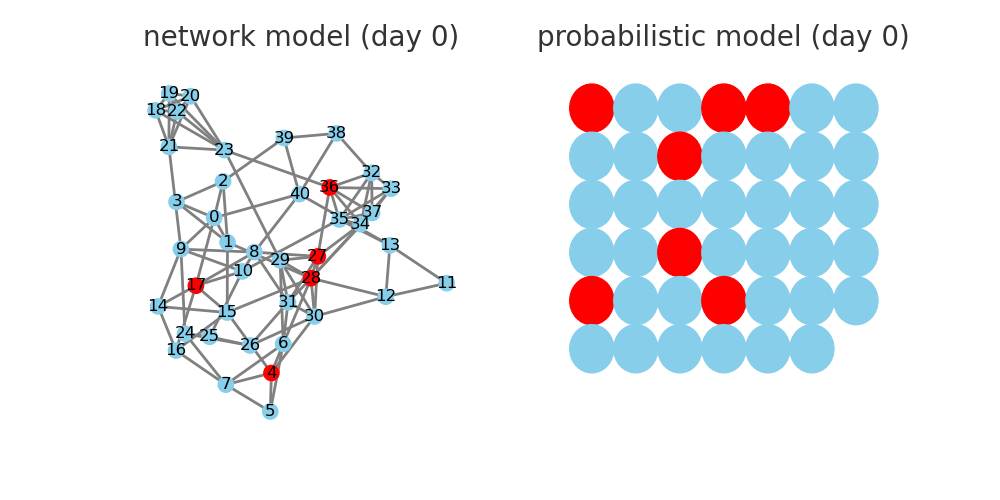

In [3]:
# Setting up parameters for the simulation
n_families = 10  # Number of families
min_family_size = 2  # Minimum number of individuals per family
max_family_size = 6  # Maximum number of individuals per family
p_intra = 1.0  # Probability of an intra-family connection
p_inter = 0.05  # Probability of an inter-family connection
p_infect = 0.1  # Probability of infection spread on contact
days = 30  # Number of days to simulate

# Creating the families
# Generate random sizes for the families
family_sizes = np.random.randint(min_family_size, max_family_size + 1, size=n_families)
n = sum(family_sizes)  # Calculate total number of individuals

# Generate community structure
# Create a network graph with families as communities
G = nx.random_partition_graph(list(family_sizes), p_intra, p_inter)

# Set up figures for plotting
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Generate positions for nodes in the network and grid models
pos_network = nx.spring_layout(G)  # Position nodes using Fruchterman-Reingold force-directed algorithm
# Calculate grid size for arranging nodes in the probabilistic model
grid_size = int(np.ceil(np.sqrt(n)))
# Arrange nodes in a grid for the probabilistic model
pos_probabilistic = {i: (i % grid_size, grid_size - 1 - i // grid_size) for i in range(n)}

# Initialize disease status for each individual in the network and probabilistic models
infected_network = {i: False for i in range(n)}  # Network model
infected_probabilistic = {i: False for i in range(n)}  # Probabilistic model
newly_infected_network = {i: False for i in range(n)}  # To track infections during each iteration in network model
newly_infected_probabilistic = {i: False for i in range(n)}  # To track infections during each iteration in probabilistic model

# Choose a random node to be patient zero (the first infected individual)
patient_zero = np.random.choice(n)
newly_infected_network[patient_zero] = True
newly_infected_probabilistic[patient_zero] = True

# Define the animation function to be used for each frame
def animate(day):
    axs[0].clear()
    axs[1].clear()
    axs[0].set_title("network model (day %d)" % day, fontsize=20, pad=10, color='#333333')  # Set title for network model subplot
    axs[1].set_title("probabilistic model (day %d)" % day, fontsize=20, pad=10, color='#333333')  # Set title for probabilistic model subplot
    
    # Simulate disease spread in network
    for node in G.nodes:
        if infected_network[node]:  # Skip if node is already infected
            continue
        for neighbor in G.neighbors(node):  # Check all neighbors of the node
            # If the neighbor is newly infected and if random number is less than infection probability
            if newly_infected_network[neighbor] and np.random.rand() < p_infect:
                newly_infected_network[node] = True
                break  # Stop checking other neighbors
    infected_network.update(newly_infected_network)  # Update the status of infected nodes in the network model

    # Simulate disease spread in probabilistic model
    for node in range(n):
        if infected_probabilistic[node]:  # Skip if node is already infected
            continue
        # If random number is less than infection probability, the node gets infected
        if np.random.rand() < p_infect:
            newly_infected_probabilistic[node] = True
    infected_probabilistic.update(newly_infected_probabilistic)  # Update the status of infected nodes in the probabilistic model

    # Draw network model
    colors = ['red' if infected_network[i] else 'skyblue' for i in range(n)]  # Assign node colors based on infection status
    nx.draw_networkx(G, pos=pos_network, node_color=colors, node_size=100, ax=axs[0], edge_color='gray', linewidths=2, width=2)
    axs[0].axis('off')  # Hide axes
    
    # Draw probabilistic model
    colors = ['red' if infected_probabilistic[i] else 'skyblue' for i in range(n)]  # Assign node colors based on infection status
    for i in range(n):
        circle = plt.Circle(pos_probabilistic[i], 0.5, color=colors[i])  # Create a circle representing the node
        axs[1].add_patch(circle)  # Add the circle to the subplot
    axs[1].set_xlim(-1, grid_size)
    axs[1].set_ylim(-1, grid_size)
    axs[1].axis('off')  # Hide axes

# Create the animation
ani = animation.FuncAnimation(fig, animate, frames=days, interval=200)  # Create an animation using the 'animate' function
ani.save("infection.gif", writer='pillow', fps=1)  # Save the animation as a GIF

# Close the figure to prevent it from being displayed
plt.close()

# Display the animation
Image(filename="infection.gif")


# SEIR Models in Epidemiology and Their Relationship to Network Theory

SEIR models are a class of mathematical models that are widely used in epidemiology to understand how diseases spread in a population. The term SEIR stands for Susceptible, Exposed, Infected, and Recovered, which are the four distinct health statuses a person can have in the model:

1. **Susceptible (S):** Individuals who have not yet contracted the disease and can potentially become infected.
2. **Exposed (E):** Individuals who have been infected but are not yet infectious themselves because the disease is in its latent period.
3. **Infected (I):** Individuals who have the disease and are capable of spreading it to the Susceptible individuals.
4. **Recovered (R):** Individuals who have recovered from the disease and now have immunity, thus can't become infected again or spread the disease.

In the SEIR model, people move from one category to the next based on certain rates defined by the model. For example, a Susceptible person becomes Exposed at a rate proportional to the number of Infected people in the population. The Exposed individuals become Infected after the latent period, and Infected people recover at a certain rate.

The SEIR model is a compartmental model, meaning it assumes that everyone in a given category is alike and that the population mixes uniformly. However, in reality, this is seldom the case. Different people have different numbers of contacts and the population isn't perfectly mixed.

This is where the principles of network theory can help refine these models. In a network-based SEIR model, the population is represented as a network of nodes (individuals) and edges (contacts between individuals). This model takes into account the structure of the social network when simulating disease spread. 

For example, a person with many contacts is more likely to become infected and to infect others than a person with few contacts. Moreover, the network structure can lead to clusters of infections and can influence the speed and pattern of disease spread. Thus, network-based SEIR models provide a more realistic representation of disease dynamics compared to traditional compartmental models.

In conclusion, SEIR models are fundamental in understanding the dynamics of infectious diseases, but their realism can be improved by incorporating the principles of network theory. This provides more nuanced predictions about how diseases will spread and can help inform more effective strategies for disease control.

# When Networks Are Not Appropriate: The Case of Astrology

Network analysis, while powerful, isn't the best tool for every job. There are situations where its application may lead to misleading results or interpretations. One of these situations, believe it or not, can be found when we look to the stars — the creation and interpretation of **constellations** and **astrology**.

---

## Spotting Patterns: Human Nature and Constellations

Humans are pattern-seeking creatures; it's in our nature. Thousands of years ago, our ancestors looked up at the night sky and began connecting the dots — or stars, in this case. They formed shapes, which became known as constellations, and assigned stories and meanings to them.

![Constellation](https://upload.wikimedia.org/wikipedia/commons/d/de/Ecliptic_path.jpg)

---
![Zodia](https://upload.wikimedia.org/wikipedia/commons/f/f8/Zodiac_Constellations.jpg)
---

## The Downside: Arbitrary Connections and Astrology

Astrology takes these constellations and assigns even deeper meanings to them, suggesting that the positions of celestial bodies at the time of our birth can influence our personalities and destinies. While it may seem like an intricate network of interconnected signs and predictions, it's important to note that these patterns are **human-made and arbitrary**. The stars in a constellation might appear close to each other from our perspective on Earth, but in reality, they could be light-years apart.

---

## Why Networks Are Inappropriate Here

The key issue here is that these connections or relationships don't exist beyond human interpretation. The stars themselves aren't related or interacting in the way that people in a social network or nodes in a computer network might be. The 'links' in this 'network' don't have any real-world significance or effect, making a network analysis approach inappropriate and misleading.

Using network analysis in such a scenario would not yield any meaningful or accurate results because the underlying data — the 'connections' between stars — doesn't truly represent a network.

---

## Takeaway: Careful Consideration in Applying Network Analysis

So, while network analysis is a robust tool for revealing insights in systems where interactions and relationships are key, it's equally important to recognize when its application may not be suitable. Misapplication can lead to spurious results or interpretations — a reminder that our tools should always match the context and nature of the problem we're tackling.

---

## When Networks Are Not Appropriate: Examples in Biology

While network analysis has seen a wide application in the field of biology, such as in the study of genetic interactions, protein-protein interactions, epidemiological models and ecological relationships, it is not always the appropriate tool to use. 

---

### Example 1: Independent Events

The key to the successful use of network analysis lies in the assumption of interactions or relationships between entities. But what if the events or entities are independent of each other? 

Take, for example, **random genetic mutations**. Mutations occur independently across various locations on the DNA, each having its own probability. It's a stretch to assume any interconnectedness or network among these mutations. After all, a mutation at one location doesn't influence the occurrence of another mutation at a different location.

![Random Genetic Mutation](https://www.verywellhealth.com/thmb/9AQDC9I4ukoFtmmQTwFuMZTBf1A=/1500x0/filters:no_upscale():max_bytes(150000):strip_icc()/GeneMutation-58b1ddab5f9b5860463c20e9.jpg)

---

### Example 2: Linear Processes

Another scenario where network analysis may not be the most appropriate tool is in situations where processes are predominantly linear or sequential, such as the **central dogma of molecular biology** (DNA to RNA to Protein). While there are complexities and exceptions, this process is largely a linear one. The coding region in the DNA gets transcribed to form RNA, which then gets translated to produce a protein.

Attempting to impose a network structure on such a linear process might overcomplicate the representation and interpretation without providing additional meaningful insights.

![Central Dogma](https://d2jx2rerrg6sh3.cloudfront.net/image-handler/ts/20181112091027/ri/673/picture/2018/11/By_Designua.jpg)

---

### Example 3: Scalability and Precision Issues

Finally, in biological systems where the scale and precision matter, the application of network models might be questionable. For example, **atomic interactions within a molecule** or **electrochemical gradients across cell membranes**. 

![Molecular Dynamic Simulation](https://www.lobos.nih.gov/animations/p3ns20-40xz.gif)

In these cases, precise mathematical models or quantum mechanical models may serve better than network models. While one can technically construct a network model of atoms within a molecule or ions across a membrane, the benefit from such a model (given the complexity of construction and interpretation) may not outweigh the insights provided by more traditional models.

---

## Takeaway: The Importance of Context

As we saw with the astrology example above, these biological examples highlight the importance of considering the context and nature of the system being studied before deciding on the use of network analysis. While network models can provide great insights into many biological phenomena, they are not a universal tool. Understanding when not to use network analysis is as crucial as knowing when to use it.


# Gene Co-Expression Network Analysis: A Guide to Functional Genomics

Gene co-expression network analysis is a powerful approach in functional genomics that allows researchers to explore complex interactions and regulatory mechanisms in gene expression data. By identifying patterns of co-expression, this method can shed light on gene functions, regulatory relationships, and biological pathways.

#### Understanding Gene Co-expression Networks

A gene co-expression network is a graphical model that maps out the relationships between genes based on their expression profiles across various conditions or tissues. In this network:
- **Nodes** represent genes or other units of gene expression, such as transcripts or proteins.
- **Edges** indicate co-expression relationships, suggesting that the connected genes might be co-regulated or functionally related.

The foundation of co-expression network analysis lies in the principle of "guilt by association." This principle posits that genes exhibiting similar expression profiles across different datasets are likely involved in related biological functions or processes.

#### Building a Co-expression Network

Building a gene co-expression network involves several key steps:

1. **Data Preparation**: Start with a matrix of gene expression data where rows are genes and columns are different samples, such as tissue types, developmental stages, or experimental conditions.

2. **Co-expression Measurement**: Calculate a measure of co-expression for each gene pair, typically using correlation coefficients such as Pearson or Spearman. This step assesses how similarly two genes behave across the sampled conditions.

3. **Threshold Application**: Apply a threshold to these co-expression measures to determine which gene pairs are significantly co-expressed. The threshold can be set based on a percentile cutoff or statistical significance, ensuring that only meaningful relationships are considered in the network.

#### Applications of Co-expression Networks

Gene co-expression networks have a wide range of applications in genomics research, including:

1. **Module Detection**: Networks can reveal modules or clusters of highly interconnected genes, often corresponding to specific biological processes or pathways.

2. **Gene Function Prediction**: By examining the network context of genes with unknown functions, their potential roles can be inferred based on known functions of co-expressed genes.

3. **Disease Gene Identification**: Analyzing changes in co-expression patterns between normal and disease states can help identify genes potentially involved in disease processes.

4. **Key Regulator Identification**: Networks can highlight hub genes, which are highly connected and may serve as crucial regulators of other genes' expression levels.

#### Conclusion

Gene co-expression network analysis is an invaluable tool in the toolkit of modern genomics, offering insights into the functional implications of gene expression patterns. It not only helps in understanding the biological machinery at a systems level but also assists in identifying potential targets for therapeutic intervention and biomarker discovery in various diseases. By leveraging this approach, researchers can uncover the intricate web of gene interactions that underpin cellular functions and responses.

## Step 1: Data Preparation

Since we are starting with the normalized counts from a DeSeq2 pipeline with genes as columns and samples as rows, we are ready to perform the gene co-expression network analysis.
However, there are additional steps that we can take to further preprocess our data. For example, you might want to consider steps like filtering for genes with highest variance (or other metrics of interest) as these might be the most informative for your co-expression network.

Let's look at the variance in the dataset first to see what an appropriate filter might be.

(array([4.640e+03, 1.567e+03, 1.199e+03, 9.570e+02, 8.140e+02, 7.180e+02,
        5.950e+02, 5.170e+02, 4.520e+02, 4.760e+02, 4.050e+02, 4.070e+02,
        3.970e+02, 4.210e+02, 4.030e+02, 4.610e+02, 5.020e+02, 5.830e+02,
        6.560e+02, 7.870e+02, 9.640e+02, 9.700e+02, 1.072e+03, 1.105e+03,
        1.057e+03, 9.420e+02, 8.530e+02, 6.630e+02, 5.630e+02, 4.720e+02,
        3.250e+02, 2.650e+02, 1.890e+02, 1.430e+02, 9.500e+01, 7.400e+01,
        5.100e+01, 4.200e+01, 2.400e+01, 1.400e+01, 6.000e+00, 9.000e+00,
        2.000e+00, 5.000e+00, 2.000e+00, 2.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00]),
 array([ 0.02788765,  0.24980061,  0.47171356,  0.69362652,  0.91553948,
         1.13745243,  1.35936539,  1.58127834,  1.8031913 ,  2.02510426,
         2.24701721,  2.46893017,  2.69084313,  2.91275608,  3.13466904,
         3.35658199,  3.57849495,  3.80040791,  4.02232086,  4.24423382,
         4.46614677,  4.68805973,  4.90997269,  5.13188564,  5.3537986 ,
         5.

Text(0.5, 0, 'Log-Variance')

Text(0, 0.5, 'Frequency')

Text(0.5, 1.0, 'Histogram of Log-Variance across Genes')

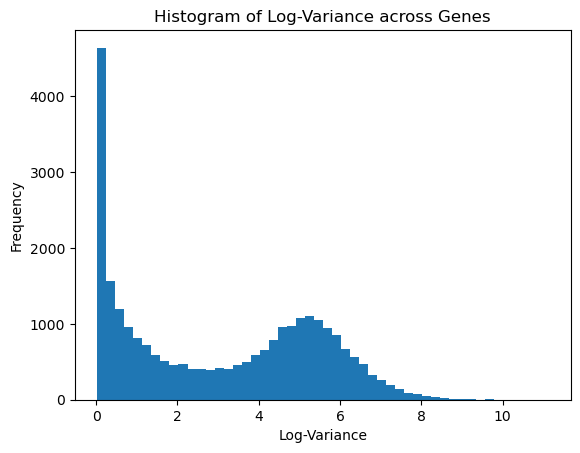

In [ ]:
# If necessary, load the melanoma_CountsNormal_filtered.csv here.
melanoma_CountsNormal_filtered = pd.read_csv('~/LECTURE_MATERIALS/DataFiles/melanoma_CountsNormal_filtered.csv',index_col = 0)

# Calculate variance for each gene
variances = melanoma_CountsNormal_filtered.var(axis=0)

# Calculate log-variances
log_variances = np.log10(variances + 1)  # add 1 to avoid taking log of 0

# Plot histogram of log-variances
plt.hist(log_variances, bins=50)
plt.xlabel('Log-Variance')
plt.ylabel('Frequency')
plt.title('Histogram of Log-Variance across Genes')
plt.show()

### Understanding the Histogram of Log-Variance across Genes

1. **X-axis (Log-Variance)**: The values on the x-axis represent the logarithm of variance in gene expression levels. Taking the logarithm helps manage the wide range of variance values, making the data more interpretable and visually manageable.

2. **Y-axis (Frequency)**: This axis shows the frequency or the number of genes that fall into each bin of log-variance values. It essentially counts how many genes have a specific level of variance in their expression.


What can we conclude from this histogram regarding:
1. **High Gene Frequency with Low Variance?**
2. **The Presence of a Secondary Peak?**

In [7]:
# Calculate variance for each gene
variances = melanoma_CountsNormal_filtered.var(axis=0)

# Calculate log-variances
log_variances =  np.log10(variances + 1) # add 1 to avoid taking log of 0

# Create a boolean mask for genes with log-variance above 4
high_variance_mask = log_variances > 4

# Apply the mask to filter the DataFrame to only high-variance genes
melanoma_highVariance = melanoma_CountsNormal_filtered.loc[:, high_variance_mask]

# Print the shape of the new DataFrame to see how many genes remain
print(melanoma_highVariance.shape)
print(melanoma_highVariance.head())

(12, 11408)
                    A1BG           A2M         AAAS         AACS       AADAT  \
Sample Title                                                                   
FM_1          445.611738  25932.375106  1655.447607  1971.831942  324.182540   
FM_2          353.629946  52609.085085  1515.083302  2280.913154  443.142527   
FM_3          531.225125  22207.378510  1722.687193  2960.766975  494.364607   
SK_MEL_28_1   360.021065   2884.519226  1886.031802  1813.157447  410.054204   
SK_MEL_28_2   352.496431   2628.671730  1863.472866  1660.520376  444.747563   

                   AAED1        AAGAB         AAK1       AAMDC         AAMP  \
Sample Title                                                                  
FM_1          927.986445  1578.579583  1231.002427  538.076174  2883.107946   
FM_2          880.759585  1878.659090  1339.373422  695.103863  2764.944143   
FM_3          686.256131  1439.728503  1039.683460  597.357233  3120.134512   
SK_MEL_28_1   571.030390  1569.5

## Step 2: Calculate Correlation Matrix

Next, we calculate the correlation between all pairs of genes across all samples. Pearson correlation is commonly used for this purpose, but Spearman correlation might be a better choice if the relationships are not linear or the data isn't normally distributed.

<Figure size 1000x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Heatmap of gene correlation')

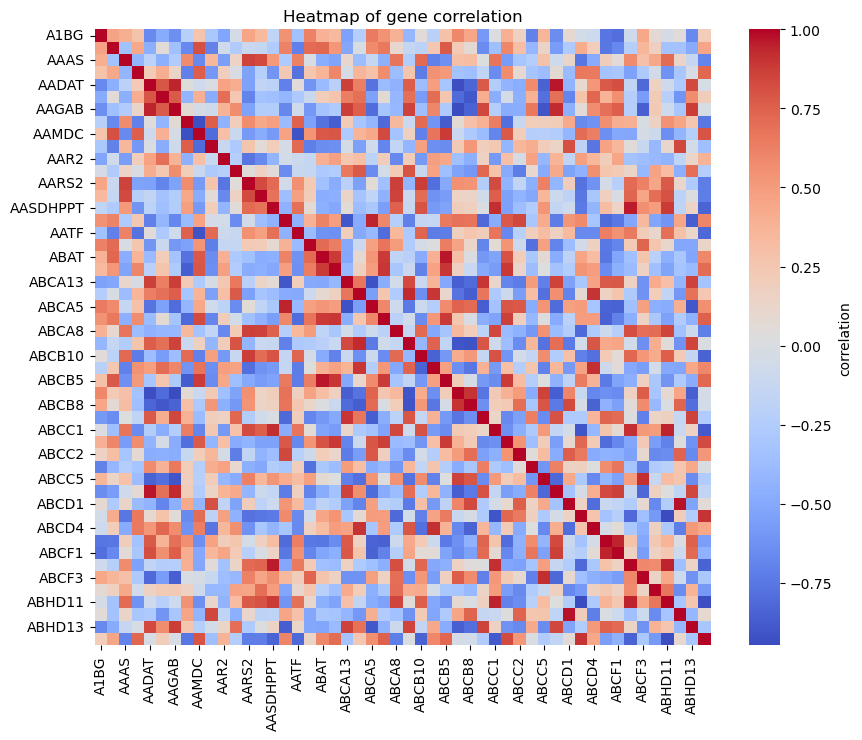

In [8]:
# Calculate correlation matrix
correlation_matrix = melanoma_highVariance.corr(method='pearson') # or 'spearman'

# To look at what this step is doing, we can plot it as a heatmap.
# We are using a subset of the correlation matrix to make the plot readable
subset_corr_matrix = correlation_matrix.iloc[:50, :50]

plt.figure(figsize=(10, 8))  # Set the figure size
sns.heatmap(subset_corr_matrix, 
            cmap='coolwarm',  # Set the color map
            square=True,  # Make the cells square
            annot=False,  # Do not annotate the cells with their values
            cbar_kws={'label': 'correlation'})  # Label the colorbar
plt.title('Heatmap of gene correlation')
plt.show()

### Understanding the Heatmap of Gene Correlation
1. **What do the colors in the heatmap represent?**
2. **Identify a gene-pair with high positive or negative correlation. What might this imply about their function or regulation?**

## Step 3: Create Adjacency Matrix

The adjacency matrix represents the network of genes. Each cell in the matrix indicates the strength of the connection (correlation) between two genes. Often, a threshold is applied to the correlation matrix to remove weak connections and simplify the network.

<Figure size 1000x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Heatmap of gene correlation')

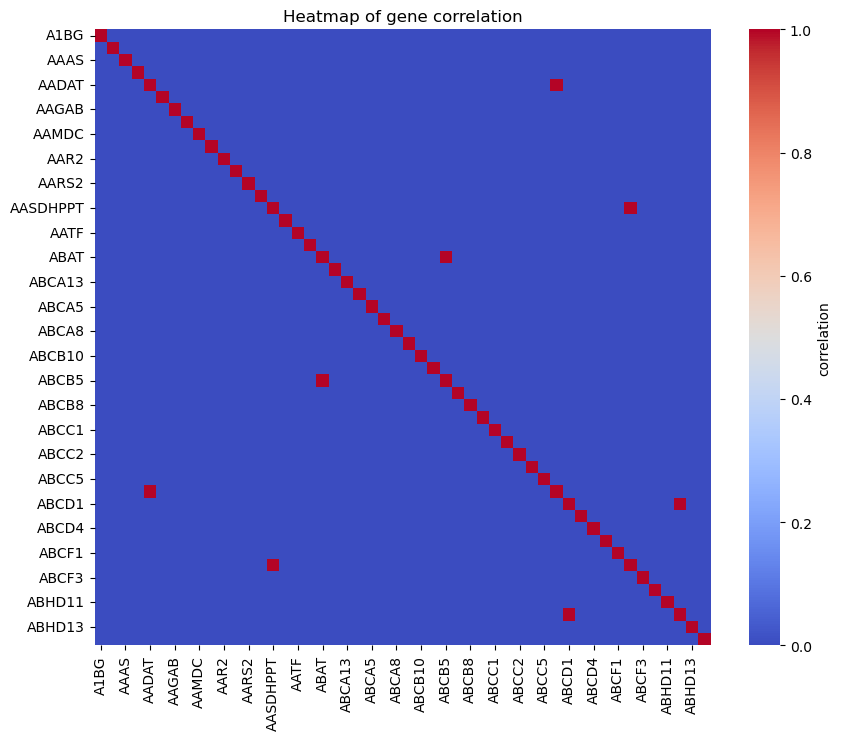

In [9]:
# Define a threshold for the absolute correlation coefficient. 
# Any pair of genes with an absolute correlation coefficient higher than this threshold will be considered highly correlated.
threshold = 0.95

# Create a boolean mask for the correlation matrix where True indicates a high correlation (above the threshold) 
# and False indicates a low correlation (below the threshold).
# The abs() function takes the absolute value of the correlation coefficients so that both positive and negative correlations are considered.
subset = abs(correlation_matrix) > threshold

# Apply the boolean mask to the correlation matrix to get a subset of the matrix with only the highly correlated gene pairs.
# Only the first 50 rows and columns are included for simplicity and visualization purposes.
subset_corr_matrix = subset.iloc[:50, :50]

# Create a new figure for the heatmap with a specific size (10 units wide by 8 units tall).
plt.figure(figsize=(10, 8))

# Generate a heatmap of the subset correlation matrix using seaborn's heatmap function.
# The color map 'coolwarm' is used, where cool colors represent low values and warm colors represent high values.
# The argument 'square=True' ensures that each cell in the heatmap is square.
# 'annot=False' means that the cells will not be annotated with their values.
# The colorbar is labeled 'correlation' using 'cbar_kws={'label': 'correlation'}'.
sns.heatmap(subset_corr_matrix, cmap='coolwarm', square=True, annot=False, cbar_kws={'label': 'correlation'})

# Add a title to the heatmap.
plt.title('Heatmap of gene correlation')

# Display the heatmap.
plt.show()


### What's happening with those diagonal correlations?

### **Understanding Adjacency Matrices**

An adjacency matrix is a square matrix where rows and columns represent graph nodes, and the element(s) recorded at the intersection of two nodes indicate the presence and type of connections, or edges, between the nodes.

##### **Types of Adjacency Matrices:**

1. **Unweighted Graphs:**
   - **Binary Values:** In unweighted graphs, the adjacency matrix contains binary values (0 or 1).
   - **Connections:** If node `i` is connected to node `j`, the matrix element `(i, j)` is set to 1; otherwise, it remains 0.

2. **Weighted Graphs:**
   - **Weight Representation:** Here, each matrix element `(i, j)` represents the weight `w` of the edge between nodes `i` and `j`.
   - **No Connection:** If there is no direct connection between node `i` and node `j`, the element `(i, j)` is typically 0 or a special value, sometimes represented as "infinity" for certain types of graph analyses.

#### **Application in Gene Expression Data**

For gene expression data, adjacency matrices are particularly useful for constructing gene co-expression networks:
- **Nodes Represent Genes:** Each node in the matrix represents a gene.
- **Edges Represent Co-Expression Relationships:** Edges indicate significant co-expression relationships, often derived from correlation matrices between gene expression profiles.

##### **Properties of Adjacency Matrices:**

- **Symmetry:** For undirected graphs, such as those typically used in gene co-expression analysis, the adjacency matrix is symmetric. This symmetry arises because if gene `i` is co-expressed with gene `j`, then gene `j` is inherently co-expressed with gene `i`.

#### **Advantages of Using Adjacency Matrices:**

- **Standard Representation:** Adjacency matrices are a standardized way of representing graphs, making them ideal for computational analysis and mathematical modeling.
- **Ease of Use:** They are straightforward to implement and manipulate using various computational tools and libraries, facilitating complex network analyses and visualizations.

Adjacency matrices not only provide a compact way to store information about large networks but also allow researchers to efficiently perform computations that help uncover the underlying biological mechanisms indicated by gene co-expression patterns.

### Thresholding the Adjacency Matrix for Gene Co-Expression Network Analysis

In gene co-expression network analysis, thresholding the adjacency matrix is a critical step to define meaningful relationships between genes based on their expression patterns. This section explains how to apply a threshold to a correlation matrix to create a boolean adjacency matrix, which effectively captures significant co-expression links between genes.

In [10]:
# Define a threshold for the absolute correlation coefficient. Any pair of genes with an absolute correlation
# coefficient higher than this threshold will be considered connected, and thus an edge will exist between them in 
# the network (adjacency matrix).
threshold = 0.95

# Create a boolean adjacency matrix from the correlation matrix. A True entry in the adjacency matrix means that the 
# absolute correlation between the corresponding pair of genes is above the threshold, indicating a connection (edge) 
# between them. The 'abs' function is used to take the absolute value of the correlation coefficients so that both
# positive and negative correlations are considered.
adjacency_matrix = abs(correlation_matrix) > threshold

# Remove self-loops from the adjacency matrix. A self-loop is an edge that connects a node to itself. Here, the 
# diagonal of the adjacency matrix is set to 0 (False), removing all self-loops, as the diagonal corresponds to the 
# correlation of each gene with itself.
np.fill_diagonal(adjacency_matrix.values, 0)

# Convert the boolean adjacency matrix to an integer adjacency matrix for further analysis. Here, True is converted to 1 
# and False is converted to 0.
adjacency_matrix = adjacency_matrix.astype(int)

# Print the shape of the adjacency matrix to get a sense of its size. The shape is a tuple that shows the number of 
# rows (genes) and columns (genes) in the adjacency matrix.
print(adjacency_matrix.shape)


(11408, 11408)


#### Try changing the threshold value. Why doesn't this change the shape of the adjacency_matrix?

<Figure size 1000x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Heatmap of Gene Adjacency')

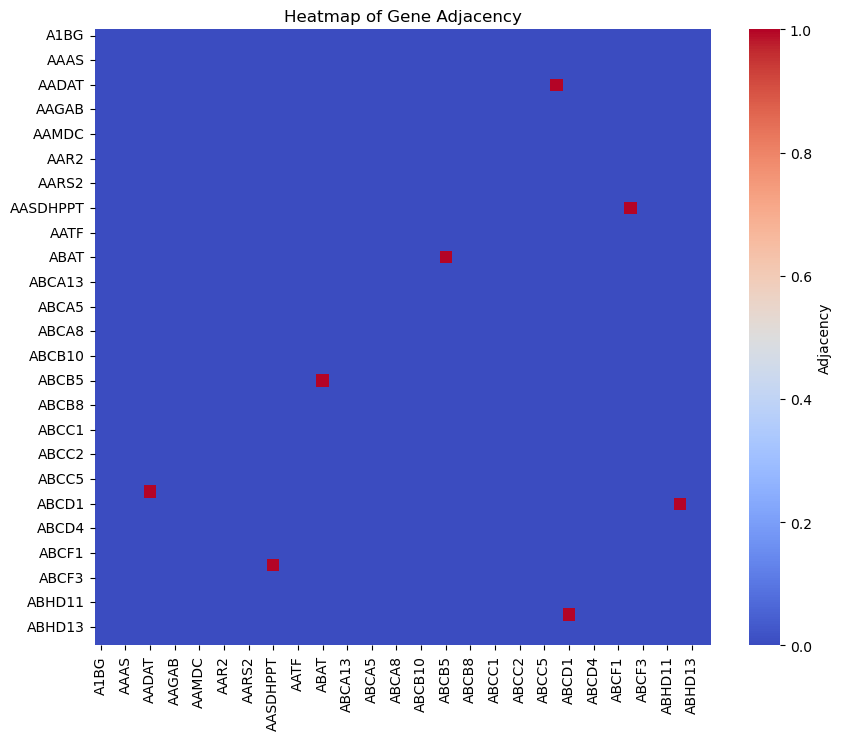

In [11]:
# Let's visualize the adjacency matrix just like we did for the correlation matrix.
# First, we create a subset of the adjacency matrix for visualization purposes.
# Here, we are selecting the first 50 rows and columns of the matrix.
subset_adj_matrix = adjacency_matrix.iloc[:50, :50]

# We then initialize a figure with a specific size (10 units by 8 units).
plt.figure(figsize=(10, 8))

# We use seaborn's heatmap function to visualize the adjacency matrix.
# The 'cmap' parameter is set to 'coolwarm', which specifies the color gradient used in the heatmap.
# The 'square' parameter is set to True, which ensures that each cell in the heatmap is square-shaped.
# The 'annot' parameter is set to False, which means that the cell values will not be displayed in the heatmap.
# The 'cbar_kws' parameter is used to customize the colorbar. Here, we set the label of the colorbar to 'Adjacency'.
sns.heatmap(subset_adj_matrix, 
            cmap='coolwarm', 
            square=True, 
            annot=False, 
            cbar_kws={'label': 'Adjacency'})

# We set the title of the heatmap to 'Heatmap of Gene Adjacency'.
plt.title('Heatmap of Gene Adjacency')

# Finally, we display the heatmap using the 'show' function from matplotlib.pyplot.
plt.show()


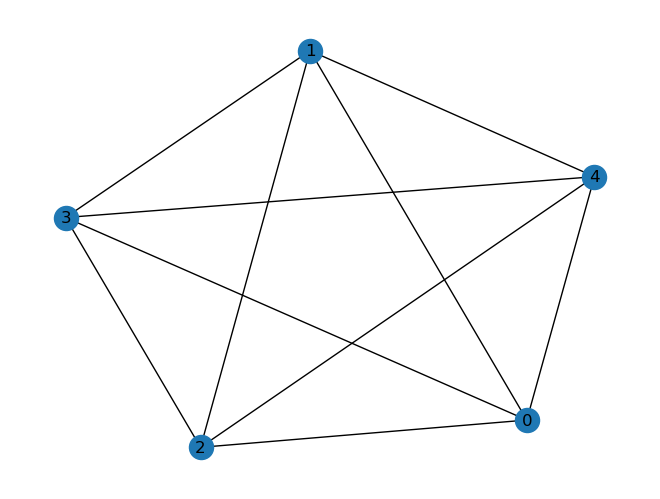

In [22]:
import networkx as nx

# The NetworkX library is used to create and manipulate complex networks (or graphs). 
# The complete_graph() function creates a complete graph, which is a graph in which 
# every pair of nodes is connected by a direct edge. In this case, the graph will 
# have 5 nodes and every node will be connected to every other node.

G = nx.complete_graph(5)

nx.draw(G, with_labels=True)
plt.show()

### Simplifying a Large Graph for Analysis
The graph object for our gene co-expression network analysis , `G`, is very large and the resulting network will be too unwieldly to work with in today's lecture. So instead, the following is an example workflow for paring it down to something more managable.

## 4. Cytoscape
Demo

## 5. Visualizing the gene co-expression network with Cytoscape
Now that we know how to use Cytoscape, let's attempt to visualize our gene co-expression network.

In [24]:
# We convert the adjacency matrix to a NetworkX graph using the from_pandas_adjacency function.
# The result is a graph G where nodes represent genes, and an edge between two nodes exists if the corresponding
# cells in the adjacency matrix are non-zero.
G = nx.from_pandas_adjacency(adjacency_matrix)

# We can draw the graph using the nx.draw function. However, large graphs might be time-consuming to draw and hard to interpret visually.
# Thus, the draw function is commented out here.
# If you'd like to see the graph, uncomment the following two lines:
# nx.draw(G, with_labels=True)
# plt.show()

# Let's get some stats to understand what we have:
# To print the number of nodes in the graph, we use the number_of_nodes() function.
print(f"Number of nodes: {G.number_of_nodes()}")

# To print the number of edges in the graph, we use the number_of_edges() function.
print(f"Number of edges: {G.number_of_edges()}")

# These statistics can help us understand the size and complexity of the gene co-expression network.

Number of nodes: 11408
Number of edges: 505646


### Simplifying a Large Graph for Analysis
The graph object, `G`, is very large and the resulting network will be too unwieldly to work with in today's lecture. So instead, the following is an example workflow for paring it down to something more managable.

In [25]:
# Calculate the average degree of the nodes in the network graph, `G`.
# Start by creating a list comprehension that iterates over the degree view of the graph.
# G.degree() returns a DegreeView object that behaves like a dictionary where keys are 
# nodes and values are their degrees (the number of edges incident to the node).
# The list comprehension extracts the degree of each node (ignoring the node itself), 
# resulting in a list of all degrees in the graph.
degrees = [val for (node, val) in G.degree()]
print("Degrees of all nodes:", degrees)  # Print the degrees of each node

# Now calculate the average degree of the nodes in the graph.
# Sum up all the degrees in the degrees list, and then divide by the total number of degrees
# (which is the same as the number of nodes in the graph). The result is the average degree 
# of the nodes in the graph G.
avg_degree = sum(degrees) / len(degrees)
print("Average degree of the nodes in the graph:", avg_degree)  # Print the average degree

Degrees of all nodes: [1, 5, 0, 0, 351, 23, 283, 23, 114, 118, 1, 4, 77, 1, 12, 83, 6, 44, 89, 69, 146, 30, 54, 53, 236, 24, 20, 39, 335, 108, 155, 59, 47, 116, 26, 0, 10, 278, 240, 4, 50, 141, 28, 23, 12, 1, 41, 159, 25, 25, 34, 38, 5, 47, 0, 2, 193, 64, 271, 124, 359, 12, 3, 149, 22, 3, 2, 121, 5, 325, 188, 2, 0, 24, 154, 131, 1, 129, 87, 61, 0, 12, 158, 122, 128, 2, 0, 47, 5, 29, 67, 0, 65, 20, 19, 0, 0, 118, 52, 340, 139, 3, 76, 15, 65, 161, 103, 32, 10, 4, 3, 243, 9, 0, 0, 1, 1, 9, 12, 116, 2, 285, 47, 0, 3, 201, 45, 6, 10, 9, 267, 0, 14, 121, 300, 228, 110, 57, 135, 7, 199, 81, 27, 3, 5, 98, 114, 61, 6, 0, 27, 7, 76, 168, 117, 188, 1, 177, 0, 24, 19, 64, 57, 5, 12, 13, 11, 69, 141, 0, 0, 50, 0, 36, 156, 19, 11, 5, 27, 112, 10, 78, 477, 265, 14, 122, 356, 530, 59, 132, 357, 17, 79, 11, 1, 268, 5, 310, 14, 4, 0, 154, 81, 71, 252, 368, 267, 265, 535, 154, 171, 22, 260, 0, 250, 50, 38, 16, 146, 23, 54, 469, 495, 215, 30, 7, 97, 566, 273, 13, 76, 347, 528, 62, 4, 27, 550, 10, 174, 79,

(array([2909.,  937.,  768.,  665.,  533.,  476.,  433.,  436.,  402.,
         333.,  341.,  265.,  240.,  238.,  213.,  218.,  185.,  132.,
         164.,  138.,   98.,  107.,   90.,   89.,   89.,   74.,   67.,
          48.,   44.,   47.,   43.,   37.,   45.,   29.,   45.,   29.,
          38.,   33.,   26.,   12.,    9.,   15.,   22.,   24.,   21.,
          19.,   17.,   16.,   18.,   14.,   24.,   20.,   17.,   15.,
          10.,   12.,   14.,    5.]),
 array([  0.        ,  10.27586207,  20.55172414,  30.82758621,
         41.10344828,  51.37931034,  61.65517241,  71.93103448,
         82.20689655,  92.48275862, 102.75862069, 113.03448276,
        123.31034483, 133.5862069 , 143.86206897, 154.13793103,
        164.4137931 , 174.68965517, 184.96551724, 195.24137931,
        205.51724138, 215.79310345, 226.06896552, 236.34482759,
        246.62068966, 256.89655172, 267.17241379, 277.44827586,
        287.72413793, 298.        , 308.27586207, 318.55172414,
        328.82758621, 33

Text(0.5, 1.0, 'Degree Histogram')

Text(0.5, 0, 'Degree')

Text(0, 0.5, 'Frequency')

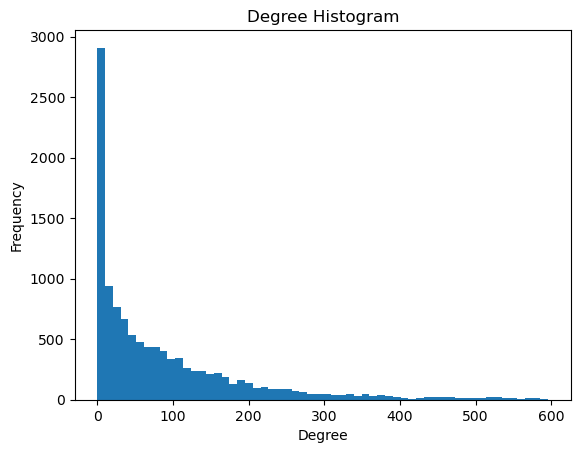

In [26]:
# Generate a sequence of the degrees of all nodes in the graph G.
# G.degree() returns a DegreeView object that represents the degree of each node in the graph 
# (the number of edges incident to the node).
degree_sequence = sorted([d for n, d in G.degree()], reverse=True)

# Create a histogram of the degree sequence and plot it.
# We are using the `bins='auto'`argument to automatically determine the optimal number
# of bins for viewing a histogram of this data.
plt.hist(degree_sequence, bins='auto')
plt.title("Degree Histogram")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

How should we interpret this information?


In the context of a gene co-expression network, one of the first questions to ask is if there are any disconnected networks. A disconnected subnetwork refers to a set of genes (nodes) and their co-expression relationships (edges) that are not connected to the rest of the network. In other words, there are no co-expression relationships between genes in this subnetwork and genes outside this subnetwork. 

Identifying these disconnected subnetworks can be an important step in the analysis of gene co-expression networks for several reasons:

1. **Understanding the structure of the network**: The presence of disconnected subnetworks indicates a modular structure in the gene co-expression network. Each disconnected subnetwork can be considered a separate module or community within the network.

2. **Simplifying the network**: Disconnected subnetworks can be analyzed independently of each other, which can simplify the analysis of large and complex networks. Instead of analyzing the entire network at once, we can focus on one subnetwork at a time.

3. **Biological implications**: Disconnected subnetworks might correspond to groups of genes that are co-regulated or functionally related. For example, they might be involved in the same biological process or pathway. Therefore, the analysis of these subnetworks could provide insights into the underlying biological mechanisms.

In the next steps, we will use NetworkX functions to identify these disconnected networks and select one for further analysis.

In [27]:
# Count the number of connected components
num_connected_components = nx.number_connected_components(G)

print(f'The graph has {num_connected_components} disconnected subnetwork(s).')

# If you want to see the nodes in each component
#for i, component in enumerate(nx.connected_components(G)):
#    print(f'Component {i+1}: {component}')

The graph has 1016 disconnected subnetwork(s).


In [28]:
# For undirected graphs, we use the NetworkX function `connected_components`, which generates connected components
# Connected components are sets of nodes where each node can be reached from any other node in the same set
# This function returns a generator, which produces sets of nodes, one for each connected component
connected_components = nx.connected_components(G)

# If your graph was directed, you'd use nx.weakly_connected_components(G) instead.
# Weakly connected components are similar, but we ignore the direction of the edges

# The max function is used to find the largest connected component in the graph.
# We use key=len to specify that we want the component with the most nodes.
# largest_component is now a set of nodes representing the largest connected component in the graph
largest_component = max(connected_components, key=len)

# We then create a subgraph of G consisting only of the nodes in largest_component
# Subgraph creates a new graph that only includes the specified nodes and the edges between them
# largest_component_subgraph is now a graph representing the largest connected component in the original graph
largest_component_subgraph = G.subgraph(largest_component)


### Let's inspect the size of the largest_component_subgraph.

Communities in networks, also known as clusters or modules, are groups of nodes that are more densely connected to each other than to the rest of the network. In other words, nodes within the same community interact more frequently among themselves than with nodes outside their community. Community detection in networks is a fundamental tool in network analysis, revealing the underlying structure of the network, and helping to understand the roles and interactions of individual nodes.

The Louvain method for community detection is one of the most popular techniques used. It's a hierarchical clustering algorithm that optimizes the modularity of a network. Modularity is a measure that quantifies the quality of an assignment of nodes to communities by evaluating how much more densely connected the nodes within a community are compared to a random expectation. A higher modularity means that the network has a stronger community structure.

The Louvain method operates in two basic steps that are repeated iteratively:

1. **Assignment Step**: Each node is initially assigned to its own community. Then, for each node, the method considers the node’s neighbors and evaluates the gain in modularity that would result if the node was removed from its current community and placed into the community of its neighbor. If such a change would increase the overall modularity of the network, the change is made.

2. **Aggregation Step**: After the assignment step, each community is contracted into a single "meta-node", and the weights of the links between these new nodes are equal to the sum of the weight of the links between nodes in the corresponding two communities.

These two steps are repeated iteratively until no increase in modularity can be achieved. At the end, you have a partition of your network into communities, which maximizes the intra-community edges and minimizes the inter-community edges. This algorithm is particularly efficient and can be applied to large-scale networks.

In [29]:
# Compute the best partition
# This line runs the Louvain community detection algorithm on our subgraph of the largest connected component. 
# The result is a generator object yielding sets of nodes, each of which forms a community.
communities = nx.algorithms.community.louvain_communities(largest_component_subgraph)

# Convert the communities to a list of lists, where each sub-list represents a module
# This line transforms the sets of nodes into lists, and then stores all these lists into a larger list.
# The result is a list of lists, where each inner list represents a community or module in the network.
modules = [list(c) for c in communities]

# Now `modules` is a list of lists, where each sub-list is a community (module)

In [30]:
# Sort modules by size (number of nodes) in descending order
# This line sorts the 'modules' list in descending order, based on the length of each module (i.e., the number of nodes in each module).
sorted_modules = sorted(modules, key=len, reverse=True)

# Print the modules for the largest connected network.
# Here, we start a loop that will print information for each module.
print("Modules for the largest connected network:")
# The enumerate function is used to get both the index (i) and the value (module) from the 'sorted_modules' list. 
# The 'start=1' argument means that indexing will start from 1 instead of the default 0.
for i, module in enumerate(sorted_modules, start=1):
    # Create a subgraph from the nodes in the current module.
    # This subgraph is a subset of the 'largest_component_subgraph', consisting only of the nodes in the current module and the edges between them.
    subgraph = largest_component_subgraph.subgraph(module)
    # Print the module number, the number of nodes, and the number of edges in the module.
    # The 'number_of_edges' function is used to count the number of edges in the subgraph.
    print(f"Module {i}: {len(module)} nodes, {subgraph.number_of_edges()} edges")


Modules for the largest connected network:
Module 1: 1589 nodes, 92467 edges
Module 2: 1399 nodes, 46896 edges
Module 3: 1215 nodes, 29161 edges
Module 4: 1181 nodes, 39623 edges
Module 5: 1134 nodes, 132029 edges
Module 6: 1107 nodes, 45767 edges
Module 7: 1026 nodes, 14352 edges
Module 8: 861 nodes, 14430 edges
Module 9: 755 nodes, 18989 edges
Module 10: 52 nodes, 432 edges
Module 11: 10 nodes, 37 edges
Module 12: 8 nodes, 8 edges
Module 13: 3 nodes, 3 edges


In [ ]:
def save_module_graphs_to_csv(modules, largest_component_subgraph, base_filename):
    """For each module, create a subgraph and save its edge list to a csv file."""
    
    # Initialize an empty list to store the module subgraphs
    module_subgraphs = []
    
    # Loop through the modules
    for i, module in enumerate(modules, start=1):
        # Create a subgraph for the current module
        # This is a new graph object that contains only the nodes in the current module and the edges between them
        subgraph = largest_component_subgraph.subgraph(module)
        
        # Add the subgraph to the list of module subgraphs
        module_subgraphs.append(subgraph)
        
        # Create a DataFrame from the edge list of the subgraph
        # Each row in the DataFrame represents an edge and contains two columns for the two nodes of the edge
        edge_list_df = nx.to_pandas_edgelist(subgraph)
        
        # Add a column for the edge weight (expression correlation)
        edge_list_df['correlation'] = [largest_component_subgraph[u][v]['weight'] for u, v in edge_list_df[['source', 'target']].values]
        
        # Define the filename for the csv file
        # The filename is the base filename with the module number appended
        csv_filename = f"{base_filename}_module_{i}.csv"
        
        # Save the edge list DataFrame to a csv file
        edge_list_df.to_csv(csv_filename, index=False)
        
    # Return the list of module subgraphs
    return module_subgraphs

module_subgraphs = save_module_graphs_to_csv(sorted_modules, largest_component_subgraph, 'path/to/your/files/base_filename')

In [ ]:
# Let's visualize module 10 using networkx and matplotlib.
import matplotlib.pyplot as plt
nx.draw(module_10_graph, with_labels=True)
plt.show()
